<a href="https://colab.research.google.com/github/ann-ahmad/Pengolahan-Citra/blob/main/Pengolahan_Citra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**ROBERT VS SOBEL**

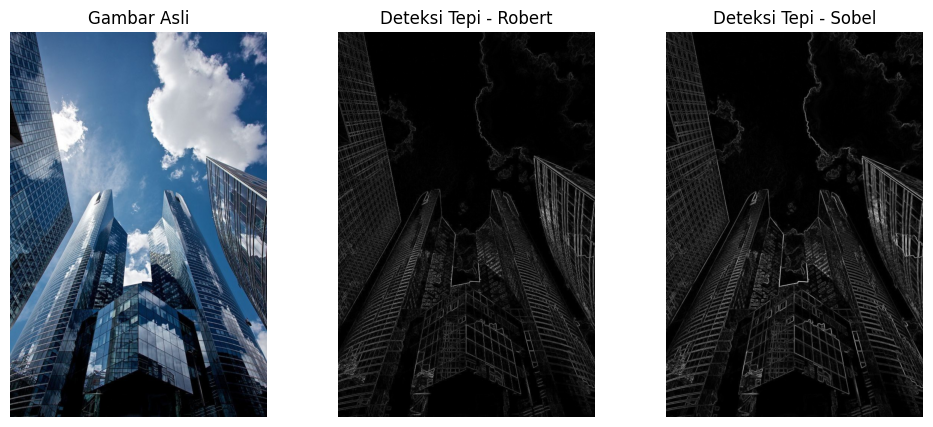

In [4]:
import imageio.v2 as imageio
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
from scipy.ndimage import convolve

url = "https://i.pinimg.com/1200x/b7/da/60/b7da608a7886435f41f66a382f5111b0.jpg"
image_path = "building.jpg"
urllib.request.urlretrieve(url, image_path)

def load_color_image(image_path):
    return imageio.imread(image_path)

def convert_to_grayscale(image):
    return np.dot(image[..., :3], [0.2989, 0.5870, 0.1140]).astype(np.float32)

# Operator Robert
roberts_x = np.array([[1, 0], [0, -1]], dtype=np.float32)
roberts_y = np.array([[0, 1], [-1, 0]], dtype=np.float32)

# Operator Sobel
sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float32)

# Deteksi tepi
def edge_detection(image, kernel_x, kernel_y):
    gx = convolve(image, kernel_x)
    gy = convolve(image, kernel_y)
    return np.sqrt(gx**2 + gy**2)

img_color = load_color_image(image_path)

img_gray = convert_to_grayscale(img_color)

# Deteksi tepi Robert dan Sobel
edge_roberts = edge_detection(img_gray, roberts_x, roberts_y)
edge_sobel = edge_detection(img_gray, sobel_x, sobel_y)

plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.imshow(img_color)
plt.title("Gambar Asli")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(edge_roberts, cmap="gray")
plt.title("Deteksi Tepi - Robert")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(edge_sobel, cmap="gray")
plt.title("Deteksi Tepi - Sobel")
plt.axis("off")

plt.show()

**SEGMENTASI CITRA CLUSTERING K-MEANS**

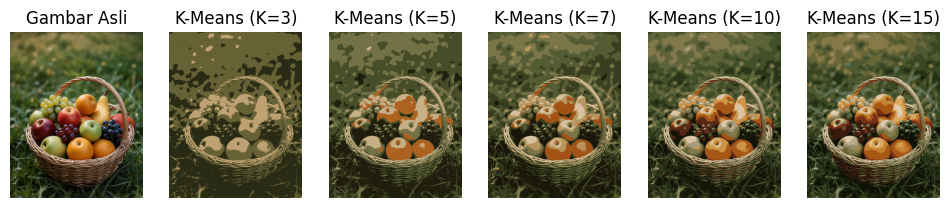

In [7]:
import numpy as np
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import urllib.request
from sklearn.cluster import KMeans

url = "https://i.pinimg.com/1200x/5e/2b/13/5e2b13c6916f1a25377c879709d13b21.jpg"
image_path = "Fruits.jpg"
urllib.request.urlretrieve(url, image_path)

def load_image(image_path):
    img = imageio.imread(image_path)
    img = img / 255.0
    return img

# K-Means Clustering
def segment_image(image, k):
    h, w, c = image.shape
    pixels = image.reshape(-1, c)

    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    kmeans.fit(pixels)
    segmented_pixels = kmeans.cluster_centers_[kmeans.labels_]

    return segmented_pixels.reshape(h, w, c)

img = load_image(image_path)

# Segmentasi dengan berbagai nilai K
k_values = [3, 5, 7, 10, 15]
segmented_images = [segment_image(img, k) for k in k_values]

plt.figure(figsize=(12, 5))
plt.subplot(1, len(k_values) + 1, 1)
plt.imshow(img)
plt.title("Gambar Asli")
plt.axis("off")

for i, k in enumerate(k_values):
    plt.subplot(1, len(k_values) + 1, i + 2)
    plt.imshow(segmented_images[i])
    plt.title(f"K-Means (K={k})")
    plt.axis("off")

plt.show()

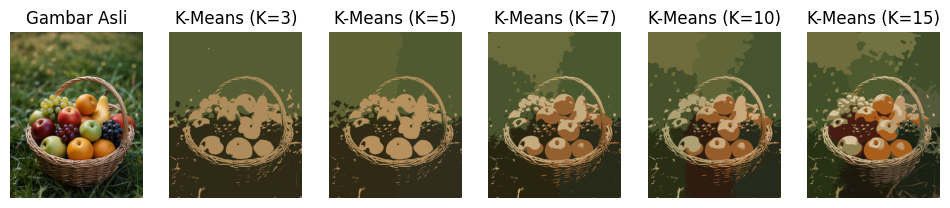

In [9]:
import numpy as np
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import urllib.request
from sklearn.cluster import KMeans

# URL gambar dari Pinterest
url = "https://i.pinimg.com/1200x/5e/2b/13/5e2b13c6916f1a25377c879709d13b21.jpg"
image_path = "Fruits.jpg"
urllib.request.urlretrieve(url, image_path)

# Fungsi untuk membaca gambar
def load_image(image_path):
    img = imageio.imread(image_path)
    img = img / 255.0  # Normalisasi warna ke [0, 1]
    return img

# K-Means Clustering dengan fitur tambahan koordinat spasial (X, Y)
def segment_image(image, k):
    h, w, c = image.shape
    pixels = image.reshape(-1, c)  # Ubah menjadi vektor warna (R, G, B)

    # Tambahkan koordinat spasial (X, Y)
    X_coords, Y_coords = np.meshgrid(np.arange(w), np.arange(h))
    spatial_features = np.column_stack((pixels, X_coords.ravel() / w, Y_coords.ravel() / h))  # Normalisasi koordinat

    # K-Means Clustering
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    kmeans.fit(spatial_features)
    segmented_pixels = kmeans.cluster_centers_[:, :3][kmeans.labels_]  # Ambil hanya warna hasil clustering

    return segmented_pixels.reshape(h, w, c)

# Load gambar
img = load_image(image_path)

# Segmentasi dengan berbagai nilai K
k_values = [3, 5, 7, 10, 15]
segmented_images = [segment_image(img, k) for k in k_values]

# Visualisasi hasil segmentasi
plt.figure(figsize=(12, 5))
plt.subplot(1, len(k_values) + 1, 1)
plt.imshow(img)
plt.title("Gambar Asli")
plt.axis("off")

for i, k in enumerate(k_values):
    plt.subplot(1, len(k_values) + 1, i + 2)
    plt.imshow(segmented_images[i])
    plt.title(f"K-Means (K={k})")
    plt.axis("off")

plt.show()
